# Likelihood-Free Ensemble Transport Filtering

See Chapter 10, Section 10.3.1: Minimizing The Energy Distance; Chapter 10, Section 10.3.2: Maximum Likelihood Estimation; Chapter 11, Section 11.1.5: Maximum Mean Discrepancy And Energy Distance.


## Problem setting

The numerical experiment uses stochastic Lorenz-63 dynamics. The state $v=(x,y,z)^\top$ follows the Lorenz-63 vector field
$$
\begin{aligned}
\dot x &= \sigma(y-x), \\
\dot y &= x(\rho-z)-y, \\
\dot z &= xy-\beta z,
\end{aligned}
$$
with fixed default parameters
$$
(\sigma,\rho,\beta)=(10,28,8/3).
$$
After one RK4 step the stochastic forecast model is
$$
v_{j+1}=\Psi(v_j)+\xi_j,
\qquad
\xi_j\sim\mathcal{N}(0,\Sigma),
\qquad
\Sigma=\sigma_v^2I_3.
$$
The observation operator measures the first coordinate,
$$
Hv=x,
$$
so
$$
y_{j+1}=Hv_{j+1}+\eta_{j+1},
\qquad
\eta_{j+1}\sim\mathcal{N}(0,\Gamma),
\qquad
\Gamma=\sigma_y^2I.
$$
The task is not to estimate $(\sigma,\rho)$; those are fixed. The task is to learn an analysis map that converts forecast particles and synthetic observations into particles conditioned on the actual observation.

Assume the physical parameters and model-error covariance $\Sigma$ are fixed. The forecast particles and synthetic observations are generated by
$$
\hat v_{j+1}^{(n)}=\Psi(v_j^{(n)})+\xi_j^{(n)},\qquad n=1,\ldots,N,
$$
$$
\hat y_{j+1}^{(n)}=H\hat v_{j+1}^{(n)}+\eta_{j+1}^{(n)},\qquad n=1,\ldots,N,
$$
where
$$
\xi_j^{(n)}\sim\mathcal{N}(0,\Sigma),\qquad
\eta_{j+1}^{(n)}\sim\mathcal{N}(0,\Gamma).
$$
Likelihood-free ensemble transport filtering learns a deterministic analysis map and applies it by conditioning on the true observation:
$$
v_{j+1}^{(n)}
=T(\hat v_{j+1}^{(n)},\hat y_{j+1}^{(n)},y^\dagger_{j+1};\theta),
\qquad n=1,\ldots,N.
$$

The energy-distance objective minimizes
$$
\mathbb{E}^{y^\dagger_{j+1}\sim\kappa_{j+1}}
\left[
\mathcal{D}_E^2
\left(T(\cdot,y^\dagger_{j+1};\theta)_\#\widehat\pi_{j+1},
\pi_{j+1}\right)
\right]
=c+L(\theta).
$$
Using the factorization $\gamma_{j+1}(v,y)=\pi_{j+1}(v)\kappa_{j+1}(y)$, the population loss is
$$
L(\theta)=
2\mathbb{E}^{(v,(v',y^\dagger_{j+1}))\sim
\widehat\pi_{j+1}\otimes\gamma_{j+1}}
|T(v,y^\dagger_{j+1};\theta)-v'|
-
\mathbb{E}^{(v,v',y^\dagger_{j+1})\sim
\widehat\pi_{j+1}\otimes\widehat\pi_{j+1}\otimes\kappa_{j+1}}
|T(v,y^\dagger_{j+1};\theta)-T(v',y^\dagger_{j+1};\theta)|.
$$
The empirical loss is
$$
L^N(\theta)=
\frac{2}{N(N-1)}\sum_{m\neq n}^{N}
|T(\hat v_{j+1}^{(n)},\hat y_{j+1}^{(m)};\theta)-\hat v_{j+1}^{(m)}|
-
\frac{1}{N(N-1)}\sum_{l\neq m,n}^{N}
|T(\hat v_{j+1}^{(n)},\hat y_{j+1}^{(l)};\theta)
-T(\hat v_{j+1}^{(m)},\hat y_{j+1}^{(l)};\theta)|.
$$

An alternative maximum-likelihood formulation uses a conditional map $S$ through a reference density $\rho(v)$:
$$
T(v,y,y^\dagger_{j+1};\theta)
=S(y^\dagger_{j+1},\cdot;\theta)^{-1}\circ S(y,v;\theta).
$$
The map $S(y,\cdot;\theta)$ is invertible in the state variable and is trained by
$$
\theta^*
=\arg\max_\theta
\frac{1}{N}\sum_{i=1}^{N}
\log\mathbb{P}_{S}(\hat v_{j+1}^{(i)}\mid \hat y_{j+1}^{(i)};\theta),
$$
where
$$
\log\mathbb{P}_{S}(\hat v_{j+1}^{(i)}\mid\hat y_{j+1}^{(i)};\theta)
=
\log\rho(S(\hat y_{j+1}^{(i)},\hat v_{j+1}^{(i)};\theta))
+
\log\left|
\det\nabla_vS(\hat y_{j+1}^{(i)},\hat v_{j+1}^{(i)};\theta)
\right|.
$$
The analysis update is
$$
v_{j+1}^{(n)}
=S(y^\dagger_{j+1},\cdot;\theta^*)^{-1}
\left(S(\hat y_{j+1}^{(n)},\hat v_{j+1}^{(n)};\theta^*)\right).
$$
When $S$ is restricted to affine maps, this composed transport recovers the EnKF update.


**Parameter exploration.**

- Increase `train_pairs` before increasing network width; the maps need enough joint state-observation examples to learn a conditional update.
- Compare `ensemble_size`: small ensembles make the empirical filtering distribution noisy, while larger ensembles reveal whether the learned map preserves spread.
- Increase `observation_noise` to make conditioning less informative; both maps should update less aggressively.
- Toggle `force_retrain` only when you want to ignore an existing checkpoint and retrain the transport maps.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `train_pairs` | `ensemble_size` | `train_epochs` | `observation_noise` | Purpose |
|---:|---:|---:|---:|---|
| 600 | 80 | 90 | 1.0 | Fast run that shows the basic transport mechanism. |
| 1200 | 100 | 120 | 1.0 | Balanced default for comparing the two objectives. |
| 2000 | 160 | 180 | 1.5 | Larger, noisier case where conservative updates are useful. |


Saved checkpoint: checkpoints/likelihood_free_ensemble_transport/594cf7564005.pt
Energy-distance map RMSE: 1.814
Maximum-likelihood composed map RMSE: 11.531


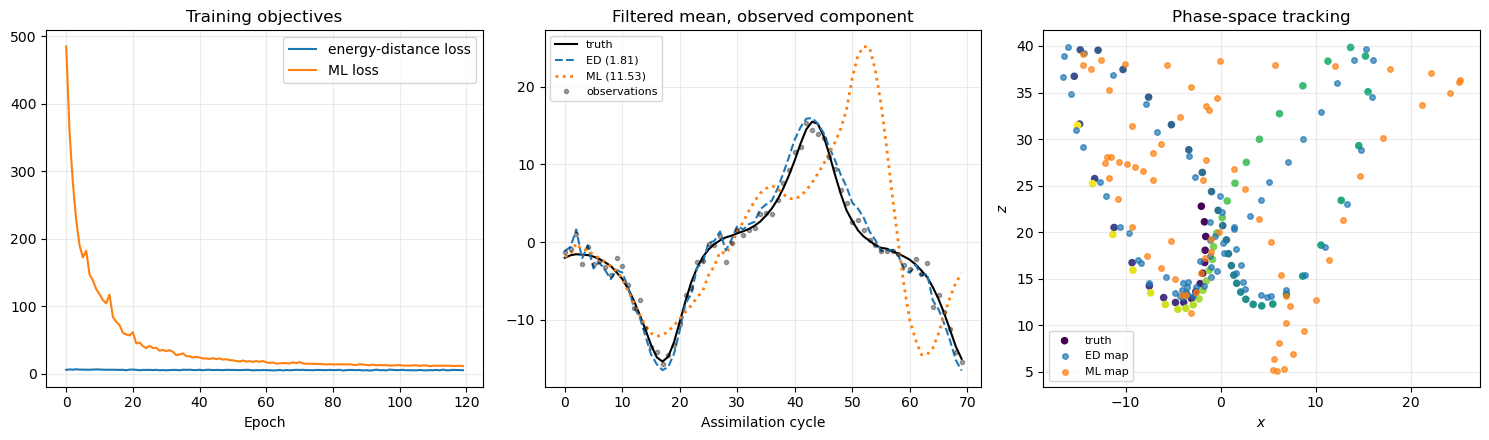

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

DEFAULTS = {
    "sigma": 10.0,
    "rho": 28.0,
    "beta": 8.0 / 3.0,
    "dt": 0.03,
    "model_noise_std": 0.05,
    "observation_noise": 1.0,
    "train_pairs": 1200,
    "ensemble_size": 100,
    "test_steps": 70,
    "hidden_dim": 64,
    "train_epochs": 120,
    "learning_rate": 1e-3,
    "random_seed": 44,
    "force_retrain": False,
}

use_default = False #@param {type:"boolean"}
train_pairs = 1200 #@param {type:"slider", min:300, max:2500, step:100}
ensemble_size = 100 #@param {type:"slider", min:40, max:250, step:10}
train_epochs = 120 #@param {type:"slider", min:30, max:300, step:30}
hidden_dim = 64 #@param {type:"slider", min:32, max:160, step:32}
observation_noise = 1.0 #@param {type:"slider", min:0.5, max:2.0, step:0.25}
force_retrain = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "train_pairs": int(train_pairs),
        "ensemble_size": int(ensemble_size),
        "train_epochs": int(train_epochs),
        "hidden_dim": int(hidden_dim),
        "observation_noise": float(observation_noise),
        "force_retrain": bool(force_retrain),
    })


def checkpoint_path(params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()[:12]
    path = Path("checkpoints") / "likelihood_free_ensemble_transport"
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{key}.pt"


torch.manual_seed(params["random_seed"])
torch.set_default_dtype(torch.float64)


def rhs(v):
    x, y, z = v[..., 0], v[..., 1], v[..., 2]
    return torch.stack([
        params["sigma"] * (y - x),
        x * (params["rho"] - z) - y,
        x * y - params["beta"] * z,
    ], dim=-1)


def rk4(v):
    dt = params["dt"]
    k1 = rhs(v)
    k2 = rhs(v + 0.5 * dt * k1)
    k3 = rhs(v + 0.5 * dt * k2)
    k4 = rhs(v + dt * k3)
    return v + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0


def burn_in_state(seed=0):
    torch.manual_seed(seed)
    x = torch.tensor([1.0, 1.0, 1.0])
    for _ in range(500):
        x = rk4(x)
    return x


def make_pairs(params):
    torch.manual_seed(params["random_seed"])
    base = burn_in_state(params["random_seed"])
    forecast = base + 3.0 * torch.randn(params["train_pairs"], 3)
    states = rk4(forecast) + params["model_noise_std"] * torch.randn_like(forecast)
    obs = states[:, :1] + params["observation_noise"] * torch.randn(params["train_pairs"], 1)
    return states, obs


class ResidualTransport(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(6, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, 3),
        )

    def forward(self, v_hat, y_hat, y_true):
        y_true_full = y_true.expand_as(y_hat)
        inp = torch.cat([v_hat, y_hat, y_true_full, y_true_full - y_hat], dim=-1)
        return v_hat + self.net(inp)


class ConditionalAffineFlow(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, 6),
        )

    def params_for(self, y):
        out = self.net(y)
        shift, log_scale = out[..., :3], torch.clamp(out[..., 3:], -3.0, 3.0)
        return shift, log_scale

    def forward(self, y, v):
        shift, log_scale = self.params_for(y)
        z = (v - shift) * torch.exp(-log_scale)
        log_det = -torch.sum(log_scale, dim=-1)
        return z, log_det

    def inverse(self, y, z):
        shift, log_scale = self.params_for(y)
        return z * torch.exp(log_scale) + shift


def energy_distance_loss(model, v, y):
    n = v.shape[0]
    perm = torch.randperm(n)
    v_a = v
    y_a = y
    v_b = v[perm]
    y_b = y[perm]
    mapped_to_b = model(v_a, y_a, y_b)
    term1 = 2.0 * torch.mean(torch.linalg.norm(mapped_to_b - v_b, dim=1))
    perm2 = torch.randperm(n)
    mapped_1 = model(v_a, y_a, y_b)
    mapped_2 = model(v[perm2], y[perm2], y_b)
    term2 = torch.mean(torch.linalg.norm(mapped_1 - mapped_2, dim=1))
    return term1 - term2


def flow_nll(flow, v, y):
    z, log_det = flow(y, v)
    log_ref = -0.5 * torch.sum(z**2, dim=-1) - 0.5 * v.shape[1] * np.log(2 * np.pi)
    return -torch.mean(log_ref + log_det)


def train_models(params):
    v, y = make_pairs(params)
    ed_model = ResidualTransport(params["hidden_dim"])
    flow = ConditionalAffineFlow(params["hidden_dim"])
    opt_ed = torch.optim.Adam(ed_model.parameters(), lr=params["learning_rate"])
    opt_flow = torch.optim.Adam(flow.parameters(), lr=params["learning_rate"])
    losses_ed, losses_ml = [], []
    batch = min(256, params["train_pairs"])
    for epoch in range(params["train_epochs"]):
        idx = torch.randint(0, params["train_pairs"], (batch,))
        vb, yb = v[idx], y[idx]
        opt_ed.zero_grad()
        loss_ed = energy_distance_loss(ed_model, vb, yb)
        loss_ed.backward()
        opt_ed.step()
        opt_flow.zero_grad()
        loss_ml = flow_nll(flow, vb, yb)
        loss_ml.backward()
        opt_flow.step()
        losses_ed.append(float(loss_ed.detach()))
        losses_ml.append(float(loss_ml.detach()))
    return {
        "ed_state": ed_model.state_dict(),
        "flow_state": flow.state_dict(),
        "losses_ed": losses_ed,
        "losses_ml": losses_ml,
    }


def simulate_truth(params):
    torch.manual_seed(params["random_seed"] + 100)
    x = burn_in_state(params["random_seed"] + 100)
    truth, obs = [], []
    for _ in range(params["test_steps"]):
        x = rk4(x) + params["model_noise_std"] * torch.randn(3)
        truth.append(x.clone())
        obs.append(x[:1] + params["observation_noise"] * torch.randn(1))
    return torch.stack(truth), torch.stack(obs)


def run_filter(ed_model, flow, params):
    truth, obs = simulate_truth(params)
    torch.manual_seed(params["random_seed"] + 200)
    ens0 = truth[0] + 2.0 * torch.randn(params["ensemble_size"], 3)
    ens_ed = ens0.clone()
    ens_ml = ens0.clone()
    means_ed, means_ml = [], []
    for y_true in obs:
        ens_ed = rk4(ens_ed) + params["model_noise_std"] * torch.randn_like(ens_ed)
        ens_ml = rk4(ens_ml) + params["model_noise_std"] * torch.randn_like(ens_ml)
        ens_ed = torch.nan_to_num(ens_ed, nan=0.0, posinf=40.0, neginf=-40.0).clamp(-40.0, 40.0)
        ens_ml = torch.nan_to_num(ens_ml, nan=0.0, posinf=40.0, neginf=-40.0).clamp(-40.0, 40.0)
        y_hat_ed = ens_ed[:, :1] + params["observation_noise"] * torch.randn(params["ensemble_size"], 1)
        y_hat_ml = ens_ml[:, :1] + params["observation_noise"] * torch.randn(params["ensemble_size"], 1)
        ens_ed = ed_model(ens_ed, y_hat_ed, y_true[None, :]).detach()
        z, _ = flow(y_hat_ml, ens_ml)
        ens_ml = flow.inverse(y_true[None, :].expand_as(y_hat_ml), z).detach()
        ens_ed = torch.nan_to_num(ens_ed, nan=0.0, posinf=40.0, neginf=-40.0).clamp(-40.0, 40.0)
        ens_ml = torch.nan_to_num(ens_ml, nan=0.0, posinf=40.0, neginf=-40.0).clamp(-40.0, 40.0)
        means_ed.append(ens_ed.mean(0))
        means_ml.append(ens_ml.mean(0))
    means_ed = torch.stack(means_ed)
    means_ml = torch.stack(means_ml)
    rmse_ed = float(torch.sqrt(torch.mean((means_ed - truth) ** 2)))
    rmse_ml = float(torch.sqrt(torch.mean((means_ml - truth) ** 2)))
    return truth, obs, means_ed, means_ml, rmse_ed, rmse_ml


ckpt = checkpoint_path(params)
if ckpt.exists() and not params["force_retrain"]:
    payload = torch.load(ckpt, map_location="cpu", weights_only=False)
    print(f"Loaded checkpoint: {ckpt}")
else:
    payload = train_models(params)
    torch.save(payload, ckpt)
    print(f"Saved checkpoint: {ckpt}")

ed_model = ResidualTransport(params["hidden_dim"])
flow = ConditionalAffineFlow(params["hidden_dim"])
ed_model.load_state_dict(payload["ed_state"])
flow.load_state_dict(payload["flow_state"])
ed_model.eval()
flow.eval()

truth, obs, means_ed, means_ml, rmse_ed, rmse_ml = run_filter(ed_model, flow, params)
print(f"Energy-distance map RMSE: {rmse_ed:.3f}")
print(f"Maximum-likelihood composed map RMSE: {rmse_ml:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(payload["losses_ed"], label="energy-distance loss")
axes[0].plot(payload["losses_ml"], label="ML loss")
axes[0].set_title("Training objectives")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

dim = 0
axes[1].plot(truth[:, dim].numpy(), "k-", lw=1.5, label="truth")
axes[1].plot(means_ed[:, dim].detach().numpy(), "C0--", label=f"ED ({rmse_ed:.2f})")
axes[1].plot(means_ml[:, dim].detach().numpy(), "C1:", lw=2, label=f"ML ({rmse_ml:.2f})")
axes[1].plot(obs[:, 0].numpy(), "ko", ms=3, alpha=0.35, label="observations")
axes[1].set_title("Filtered mean, observed component")
axes[1].set_xlabel("Assimilation cycle")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].scatter(truth[:, 0].numpy(), truth[:, 2].numpy(), c=np.arange(len(truth)), cmap="viridis", s=20, label="truth")
axes[2].scatter(means_ed[:, 0].detach().numpy(), means_ed[:, 2].detach().numpy(), s=16, alpha=0.7, label="ED map")
axes[2].scatter(means_ml[:, 0].detach().numpy(), means_ml[:, 2].detach().numpy(), s=16, alpha=0.7, label="ML map")
axes[2].set_title("Phase-space tracking")
axes[2].set_xlabel("$x$")
axes[2].set_ylabel("$z$")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
